In [1]:
import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot(title, label, x, result, expected, interval=None):
    if interval is not None:
        plt.axis([-10.1, 10.1, min(result), max(result)])
    plt.plot(x, expected, label=f'Ground truth')
    plt.plot(x, result, label=f'Sequre {label}')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

def mae(result, expected):
    return np.mean(np.abs(np.array(result) - np.array(expected)))

def mxae(result, expected):
    return np.max(np.abs(np.array(result) - np.array(expected)))

def by_interval(df):
    for interval, group in df.groupby('Interval'):
        display(group)

In [51]:
""" Core methods """

# Until Codon Jupyter is fixed: Read the data from files
show_plots = False

dump_folder = "dump"
dump_files = [
    "decor_trig",
    "decor",
    "fourier",
    "cheby",
    "taylor"
    ]
nbit_fs = [64]
intervals_count = 1
cps = [0, 1]
exclude = []

df_data = {
    'Method': [],
    'Interval': [],
    'MAE': [],
    'MXAE': [],
    'Runtime (avg)': [],
    'Runtime (std)': [],
    'Partitions count': [],
    'Truncations count': [],
    'Rounds': []
    }

df_waves = {
    'x': [],
    'Method': [],
    'Expected': [],
    'Result': []
    }

for cp in cps:
    df_data[f'Bytes sent CP{cp}'] = []
    df_data[f'Requests sent CP{cp}'] = []

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for i in range(intervals_count):
            for cp in cps:
                try:
                    with open(f"{dump_folder}/{dump_file}_{i}_{nbit_f}_CP{cp}.p", "rb") as f:
                        data = pickle.load(f)
                        x = data['x']
                        interval = f"({round(min(x), 2)}, {round(max(x), 2)})"
                        for k, v in data.items():
                            if not k.endswith('_result'):
                                continue

                            skip = False
                            for exclude_item in exclude:
                                if exclude_item in k:
                                    skip = True
                                    break
                            
                            if skip:
                                continue

                            k = k.replace('_result', '')
                            expected = data[f"{k}_expected"]

                            runtime_avg = round(data[f"{k}_time"][0], 5)
                            runtime_std = round(data[f"{k}_time"][1], 5)
                            bytes_sent = int(data[f"{k}_bytes_sent"][0])
                            send_requests = int(data[f"{k}_send_requests"][0])
                            partitions_count = int(data[f"{k}_partitions_count"][0])
                            truncations_count = int(data[f"{k}_truncations_count"][0])
                            rounds = int(data[f"{k}_rounds"][0])
                            
                            if cp == 1:
                                df_data['Method'].append(f"{k}_{nbit_f}")
                                df_data['Interval'].append(interval)
                                df_data['MAE'].append(mae(v, expected))
                                df_data['MXAE'].append(mxae(v, expected))

                                df_data['Runtime (avg)'].append(runtime_avg)
                                df_data['Runtime (std)'].append(runtime_std)
                                df_data['Partitions count'].append(partitions_count)
                                df_data['Truncations count'].append(truncations_count)
                                df_data['Rounds'].append(rounds)

                            df_data[f'Bytes sent CP{cp}'].append(bytes_sent)
                            df_data[f'Requests sent CP{cp}'].append(send_requests)

                            if cp == 1 and interval == "(-9.42, 9.42)":
                                df_waves['x'].append(x)
                                df_waves['Method'].append(f"{k}_{nbit_f}")
                                df_waves['Expected'].append(expected)
                                df_waves['Result'].append(v)

                            if show_plots and cp == 1:
                                plot(f"{k} {nbit_f} frac bits on {interval}", k, x, v, expected)
                except FileNotFoundError:
                    print(f"Could not find {dump_folder}/{dump_file}_{i}_{nbit_f}.p")

# Calculate total network overhead as the sum of bytes sent by both parties
if cps == [0, 1]:
    df_data[f'Bytes sent total'] = [
        df_data[f'Bytes sent CP0'][i] + df_data[f'Bytes sent CP1'][i] * 2
        for i in range(len(df_data['Method']))
    ]

df = pd.DataFrame(df_data)

In [52]:
if df.empty:
    raise ValueError("DataFrame is empty")

display_methods = [
    "sin_", "cos_", "tan_", "cot", "exp",
    "sigmoid", "sinh", "cosh", "tanh",
    "sqrt", "log", "mul_inv", "polynomial"]

for method in display_methods:
    display(by_interval(df[df['Method'].str.contains(method)].sort_values(by='MAE')))

,Method,Interval,MAE,MXAE,Runtime (avg),Runtime (std),Partitions count,Truncations count,Rounds,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1,Bytes sent total
1,decor_sin_64,"(-20.0, 20.0)",6.350597e-16,3.108624e-15,0.04079,0.00008,1,1,2,64064,8,32032,4,128128
192,chebyshev_50_sin_clenshaw_64,"(-20.0, 20.0)",3.737177e-15,3.907985e-14,2.12950,0.00114,51,52,103,2466464,308,1649648,206,5765760
200,chebyshev_60_sin_clenshaw_64,"(-20.0, 20.0)",5.405733e-15,8.437695e-14,2.53378,0.00467,61,62,123,2946944,368,1969968,246,6886880
154,chebyshev_65_sin_clenshaw_64,"(-20.0, 20.0)",5.951602e-15,1.342260e-13,2.74954,0.00356,66,67,133,3187184,398,2130128,266,7447440
190,chebyshev_70_sin_clenshaw_64,"(-20.0, 20.0)",8.068688e-15,2.700062e-13,2.95852,0.00079,71,72,143,3427424,428,2290288,286,8008000
126,chebyshev_55_sin_clenshaw_64,"(-20.0, 20.0)",1.021883e-14,2.028377e-13,2.33679,0.00157,56,57,113,2706704,338,1809808,226,6326320
105,chebyshev_45_sin_clenshaw_64,"(-20.0, 20.0)",6.154532e-14,1.846301e-13,1.92292,0.00222,46,47,93,2226224,278,1489488,186,5205200
184,chebyshev_40_sin_clenshaw_64,"(-20.0, 20.0)",3.421156e-10,5.824827e-10,1.71643,0.00098,41,42,83,1985984,248,1329328,166,4644640
183,chebyshev_35_sin_clenshaw_64,"(-20.0, 20.0)",6.555618e-08,1.758356e-07,1.50855,0.00224,36,37,73,1745744,218,1169168,146,4084080
174,chebyshev_30_sin_clenshaw_64,"(-20.0, 20.0)",6.190026e-05,1.134958e-04,1.30367,0.00929,31,32,63,1505504,188,1009008,126,3523520


None

,Method,Interval,MAE,MXAE,Runtime (avg),Runtime (std),Partitions count,Truncations count,Rounds,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1,Bytes sent total
0,decor_cos_64,"(-20.0, 20.0)",6.030801e-16,2.886580e-15,0.04078,0.00003,1,1,2,64064,8,32032,4,128128
136,chebyshev_50_cos_clenshaw_64,"(-20.0, 20.0)",2.876912e-15,2.076117e-14,2.13186,0.00187,51,52,103,2466464,308,1649648,206,5765760
143,chebyshev_60_cos_clenshaw_64,"(-20.0, 20.0)",3.620359e-15,4.229950e-14,2.52941,0.02132,61,62,123,2946944,368,1969968,246,6886880
161,chebyshev_65_cos_clenshaw_64,"(-20.0, 20.0)",4.043753e-15,5.850875e-14,2.74778,0.00070,66,67,133,3187184,398,2130128,266,7447440
142,chebyshev_70_cos_clenshaw_64,"(-20.0, 20.0)",4.864503e-15,1.240119e-13,2.94968,0.00774,71,72,143,3427424,428,2290288,286,8008000
117,chebyshev_55_cos_clenshaw_64,"(-20.0, 20.0)",5.469394e-15,8.787415e-14,2.33152,0.00389,56,57,113,2706704,338,1809808,226,6326320
123,chebyshev_45_cos_clenshaw_64,"(-20.0, 20.0)",2.711929e-13,4.510836e-13,1.92256,0.00179,46,47,93,2226224,278,1489488,186,5205200
169,chebyshev_40_cos_clenshaw_64,"(-20.0, 20.0)",8.858140e-11,2.457943e-10,1.71673,0.00026,41,42,83,1985984,248,1329328,166,4644640
132,chebyshev_35_cos_clenshaw_64,"(-20.0, 20.0)",2.178732e-07,3.810601e-07,1.50331,0.00228,36,37,73,1745744,218,1169168,146,4084080
167,chebyshev_30_cos_clenshaw_64,"(-20.0, 20.0)",2.244094e-05,5.670996e-05,1.29953,0.02667,31,32,63,1505504,188,1009008,126,3523520


None

None

...

None

None

None

,Method,Interval,MAE,MXAE,Runtime (avg),Runtime (std),Partitions count,Truncations count,Rounds,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1,Bytes sent total
5,decor_polynomial_64,"(-20.0, 20.0)",3.954361e-12,3.274181e-11,0.19607,0.02024,28,3,8,344528,50,328720,66,1001968


None

In [53]:
import re

def by_name(name, df):
    return df[df['Method'].str.startswith(name)]

def plot_accuracy_vs_perf(
        df, methods=["sin", "cos", "exp", "sigmoid"],
        metric="Runtime (avg)", intervals=["(-20.0, 20.0)"],
        approaches=["decor", "chebyshev", "fourier", "taylor"],
        markers=["o", "s", "^", "v"], colors=["tab:blue", "tab:orange", "tab:green", "tab:red"],
        remove_outliers=False, arangement="horizontal",
        print_legend=False, print_labels=False, force_labels=False):
    
    if arangement == "horizontal":
        fig, axs = plt.subplots(1, len(methods), figsize=(5 * len(methods), 5))
    elif arangement == "vertical":
        fig, axs = plt.subplots(len(methods), 1, figsize=(5, 5 * len(methods)))
    elif arangement == "square":
        n = int(np.ceil(np.sqrt(len(methods))))
        fig, axs = plt.subplots(n, n, figsize=(5 * n, 5 * n))
        axs = axs.flatten()
    else:
        raise ValueError(f"Unknown arangement: {arangement}")
    for idx, method in enumerate(methods):
        ax = axs[idx]
        ax.grid(True)


        filtered_df = df[df['Method'].str.contains(f"{method}_")]
        filtered_df = filtered_df[
            ~filtered_df['Method'].str.contains('_decor') &
            (~filtered_df['Method'].str.contains('_naive') |
             filtered_df['Method'].str.contains('taylor_'))
        ]
        filtered_df['Method'] = filtered_df['Method'].str.replace(f"{method}_", "", regex=False)
        
        if remove_outliers:
            filtered_df = filtered_df[filtered_df['MAE'] < 0.5]
        
        # Convert MAE to accuracy
        filtered_df['MAE'] = filtered_df['MAE'].apply(lambda x: -math.log2(x) if x > 0 else 100)
        
        for interval, group in filtered_df.groupby('Interval'):
            if interval not in intervals:
                print(f"Skipping interval {interval}")
                continue
            for approach, marker, color in zip(approaches, markers, colors):
                for nbit_f in nbit_fs:
                    filtered_group = group[
                        group['Method'].str.startswith(approach) &
                        group['Method'].str.endswith(f"{nbit_f}")
                    ].sort_values(by=[metric, "MAE"])
                    if filtered_group.empty:
                        continue
                    if any(a in approach for a in ["chebyshev", "fourier", "taylor"]):
                        ax.plot(
                            filtered_group[metric], filtered_group["MAE"],
                            label=approach.capitalize(), 
                            linestyle='--' if nbit_f == 64 else '-', marker=marker, linewidth=2,
                            markersize=10,
                            color=color
                        )
                        if "chebyshev" in approach or force_labels:
                            # Add label to each Chebyshev point
                            label_idx = 0
                            for x, y, name in zip(filtered_group[metric], filtered_group["MAE"], filtered_group['Method']):
                                label_idx += 1
                                if label_idx % 2 == 1:
                                    continue
                                # Try to parse first number from the left in approach string
                                match = re.search(r'\d+', name)
                                label = match.group(0) if match else name
                                ax.text(x, y, label, fontsize=19, ha='right', va='bottom')
                    else:
                        ax.scatter(
                            filtered_group[metric], filtered_group["MAE"],
                            label=approach.capitalize(), marker=marker, s=150,
                            color=color
                        )
            if print_labels:
                ax.set_title(f"{method} at {interval}")
                ax.set_xlabel(metric)
                ax.set_ylabel("Accuracy: -log2(MAE)")
            ax.tick_params(axis='both', which='major', labelsize=19)
            ax.tick_params(axis='both', which='minor', labelsize=19)
        if idx == len(methods) - 1 and print_legend:
            ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

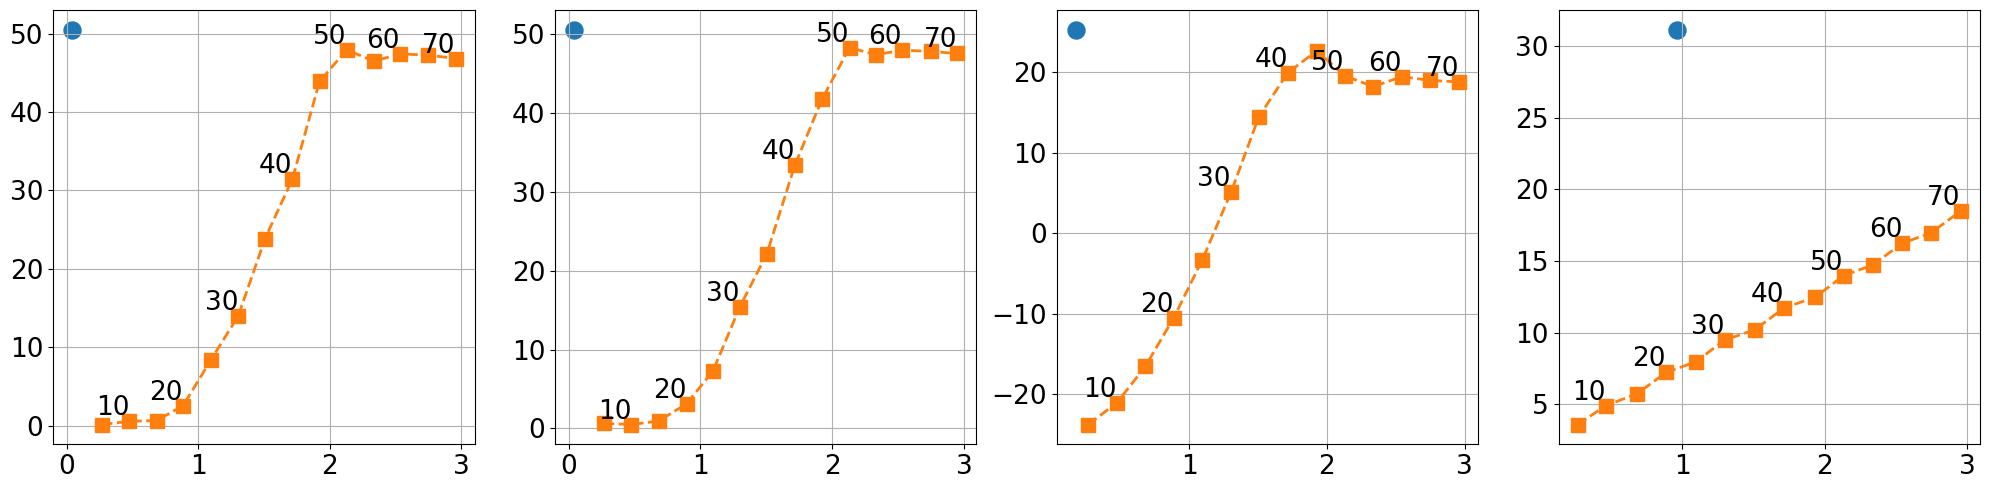

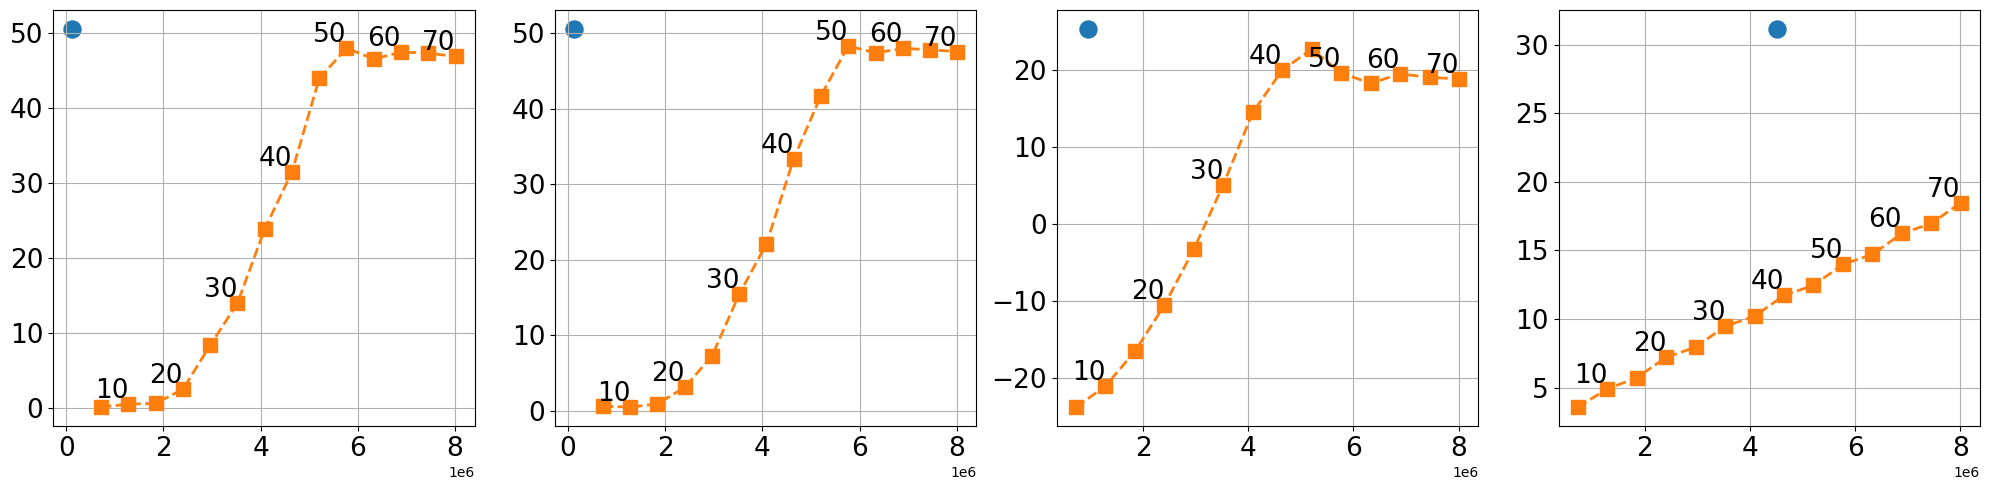

In [54]:
plot_accuracy_vs_perf(df, metric="Runtime (avg)", approaches=["decor", "chebyshev"])
plot_accuracy_vs_perf(df, metric="Bytes sent total", approaches=["decor", "chebyshev"])

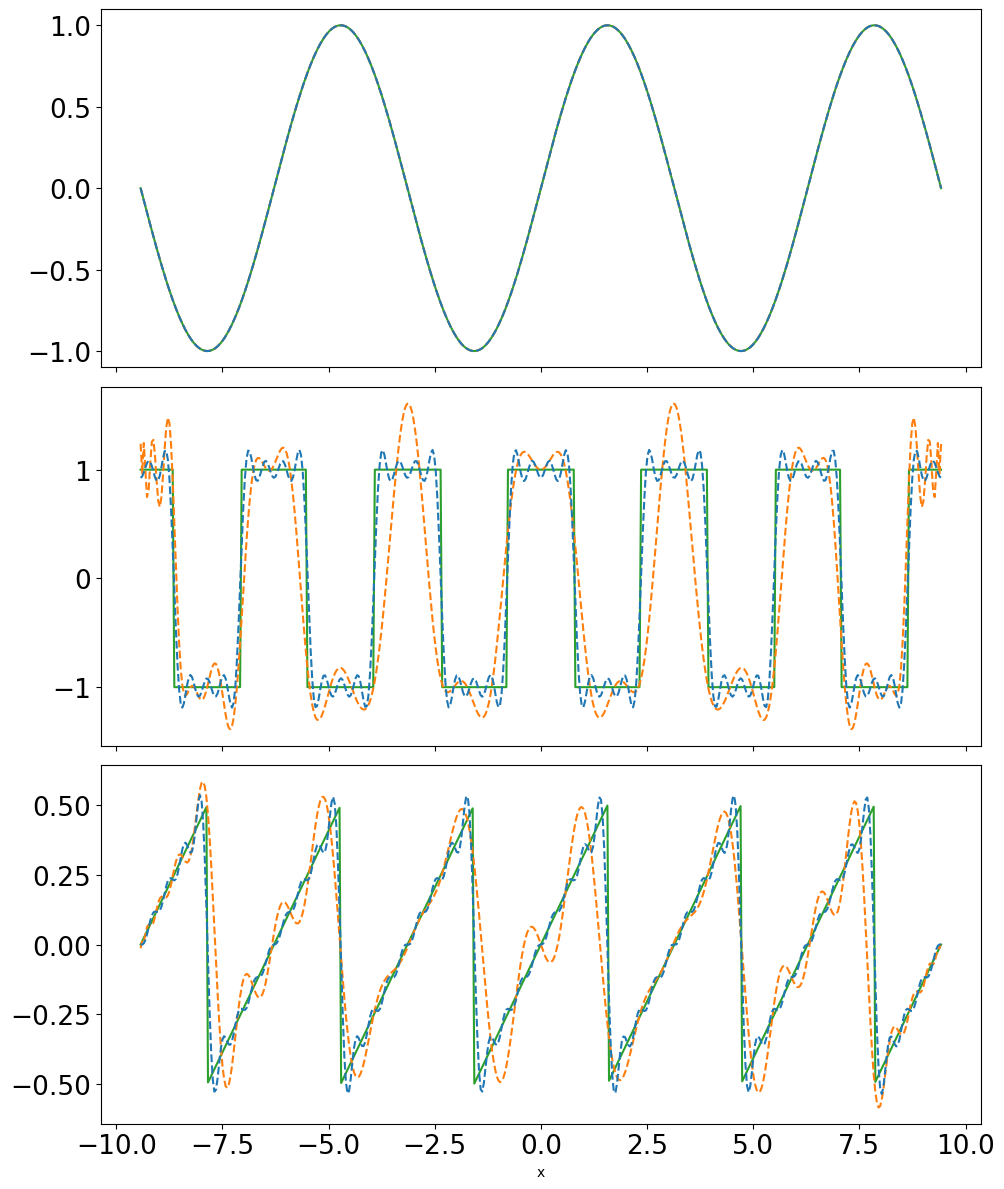

In [29]:
# Plot sine, square wave, and sawtooth wave results and expected for degree, Chebyshev and Fourier

wave_types = ['sin', 'square', 'sawtooth']
degree = 50
approaches = ['chebyshev', 'fourier']
colors = ['tab:green', 'tab:orange', 'tab:blue']
print_labels = False

fig, axs = plt.subplots(len(wave_types), 1, figsize=(10, 4 * len(wave_types)), sharex=True)

for idx, wave in enumerate(wave_types):
    ax = axs[idx]
    mask = [
            (wave in m) and
            (f'_{degree}' in m)
            for m in df_waves['Method']
        ]
    if not any(mask):
        continue
    
    x = np.array(df_waves['x'])[mask][0]
    ground_truth = np.array(df_waves['Expected'])[mask][0]
    ax.plot(x, ground_truth, label=f'Ground truth', color=colors[0])
    for i, approach in enumerate(approaches):
        mask = [
            (wave in m) and
            (approach in m) and
            (f'_{degree}' in m)
            for m in df_waves['Method']
        ]
        if not any(mask):
            continue
        result = np.array(df_waves['Result'])[mask][0]
        x = np.array(df_waves['x'])[mask][0]
        ax.plot(
            x, result,
            label=f'{"Decor " if "fourier" in approach else ""}{approach.capitalize()}',
            linestyle='--', color=colors[i + 1])
    
    ax.tick_params(axis='both', which='major', labelsize=19)
    ax.tick_params(axis='both', which='minor', labelsize=19)
    if print_labels:
        ax.set_title(f'{wave.capitalize()} Wave (Degree {degree})')
        if idx == 0:
            ax.legend()


plt.xlabel('x')
plt.tight_layout()
plt.show()

In [ ]:
display(by_interval(df[df['Method'].str.contains("sawtooth")].sort_values(by='MAE')))

Skipping interval (-0.79, 0.79)
Skipping interval (-20.0, 20.0)
Skipping interval (0.79, 2.36)
Skipping interval (-0.79, 0.79)
Skipping interval (-20.0, 20.0)
Skipping interval (0.79, 2.36)
Skipping interval (-0.79, 0.79)
Skipping interval (-20.0, 20.0)
Skipping interval (0.79, 2.36)


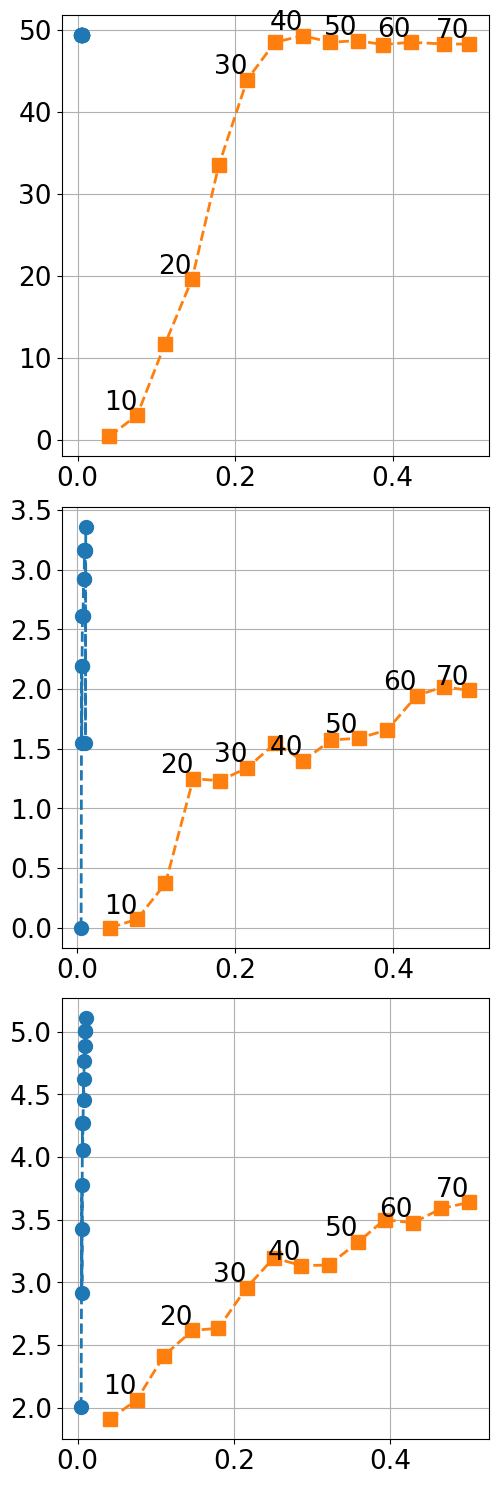

Skipping interval (-0.79, 0.79)
Skipping interval (-20.0, 20.0)
Skipping interval (0.79, 2.36)
Skipping interval (-0.79, 0.79)
Skipping interval (-20.0, 20.0)
Skipping interval (0.79, 2.36)
Skipping interval (-0.79, 0.79)
Skipping interval (-20.0, 20.0)
Skipping interval (0.79, 2.36)


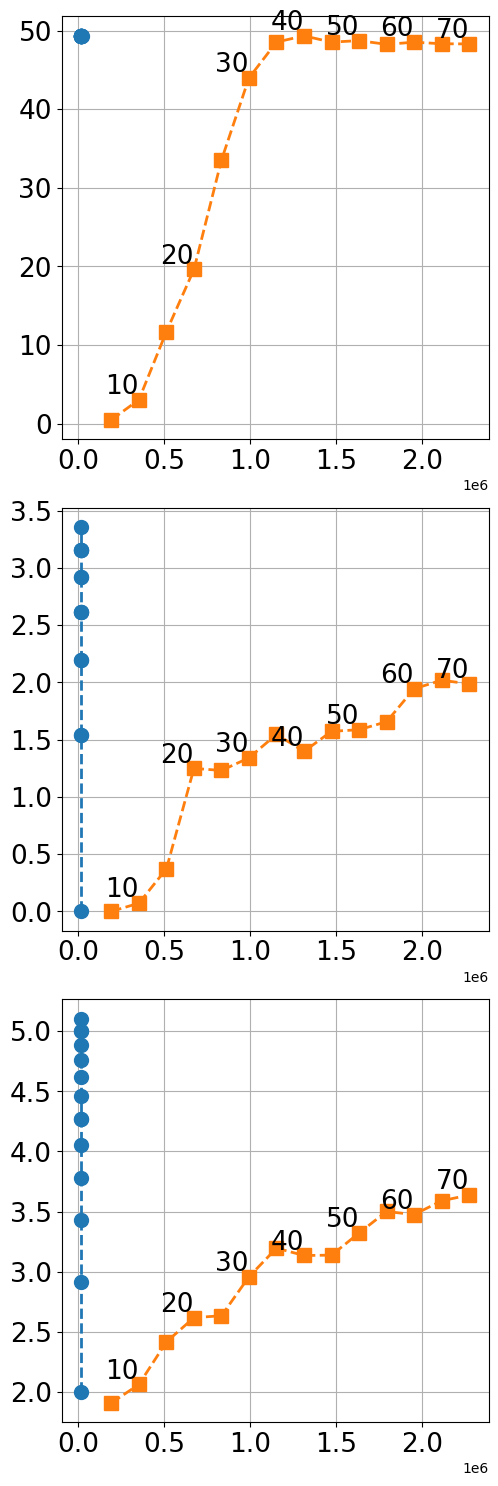

In [33]:
plot_accuracy_vs_perf(
        df, methods=["sin", "square", "sawtooth"],
        metric="Runtime (avg)", intervals=["(-9.42, 9.42)"],
        approaches=["fourier", "chebyshev"],
        arangement="vertical")
plot_accuracy_vs_perf(
        df, methods=["sin", "square", "sawtooth"],
        metric="Bytes sent CP1", intervals=["(-9.42, 9.42)"],
        approaches=["fourier", "chebyshev"],
        arangement="vertical")

In [3]:
""" E2E apps """

# Until Codon Jupyter is fixed: Read the data from files
dump_folder = "dump"
dump_files = [
    # "log_reg",
    # "mnist",
    # "dti",
    # "gwas",
    "siren",
    "siren_cheby",
    # "siren_cheby_reduced",
    # "medmnist"
    ]
nbit_fs = [64]
cps = [0, 1]

df_data = {
    'Method': [],
    'Accuracy': [],
    'Loss': [],
    'Runtime': [],
    'Partitions count': [],
    'Truncations count': []
    }

df_gwas_betas = {
    'Method': [],
    'Betas': []
    }

df_siren_images = {
    'Method': [],
    'Images': []
    }

for cp in cps:
    df_data[f'Bytes sent CP{cp}'] = []
    df_data[f'Requests sent CP{cp}'] = []

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for cp in cps:
            try:
                with open(f"{dump_folder}/{dump_file}_{nbit_f}_CP{cp}.p", "rb") as f:
                    data = pickle.load(f)
                    for k, v in data.items():
                        if "gwas_plaintext" in k and "_betas" in k:
                            df_gwas_betas['Method'].append(f"{k}_{nbit_f}")
                            df_gwas_betas['Betas'].append(data[k])
                        if not k.endswith('_time'):
                            continue

                        k = k.replace('_time', '')
                        accuracy = np.array(data.get(f"{k}_accuracy", [-1])).mean()
                        loss = np.array(data.get(f"{k}_loss", [-1])).mean()
                        runtime = round(data.get(f"{k}_time", [-1])[0], 5)
                        bytes_sent = int(data.get(f"{k}_bytes_sent", [-1])[0])
                        send_requests = int(data.get(f"{k}_send_requests", [-1])[0])
                        partitions_count = int(data.get(f"{k}_partitions_count", [-1])[0])
                        truncations_count = int(data.get(f"{k}_truncations_count", [-1])[0])

                        if cp == 1:
                            df_data['Method'].append(f"{k}_{nbit_f}")
                            df_data['Accuracy'].append(accuracy)
                            df_data['Loss'].append(loss)
                            df_data['Runtime'].append(runtime)
                            df_data['Partitions count'].append(partitions_count)
                            df_data['Truncations count'].append(truncations_count)

                            if dump_file == "gwas":
                                df_gwas_betas['Method'].append(f"{k}_betas_{nbit_f}")
                                df_gwas_betas['Betas'].append(data[f"{k}_betas"])
                            if dump_file.startswith("siren"):
                                df_siren_images['Method'].append(f"{k}_img_{nbit_f}")
                                df_siren_images['Images'].append(data[f"{k}_img"])
                        
                        df_data[f'Bytes sent CP{cp}'].append(bytes_sent)
                        df_data[f'Requests sent CP{cp}'].append(send_requests)
            except FileNotFoundError:
                print(f"Could not find {dump_folder}/{dump_file}_{nbit_f}_CP{cp}.p")

e2e_df = pd.DataFrame(df_data)
gwas_betas_df = pd.DataFrame(df_gwas_betas)
siren_images_df = pd.DataFrame(df_siren_images)

In [4]:
siren_images_df

,Method,Images
0,siren_organ_plain_0_img_64,"[-0.9912535195652256, -1.0195812046527188, -1...."
1,siren_chest_decor_0_img_64,"[-0.005576497789590268, -0.7016631230756992, -..."
2,siren_organ_decor_0_img_64,"[-0.9526147530855429, -1.023562501378162, -0.9..."
3,siren_oct_plain_0_img_64,"[-0.8135516994260534, -0.8563078126186319, -0...."
4,siren_oct_decor_0_img_64,"[-0.818534705668398, -0.7960517885080024, -0.7..."
5,siren_chest_plain_0_img_64,"[0.031765611543390804, -0.7594025357681435, -1..."
6,siren_organ_chebyshev_10_img_64,"[0.06893864267145715, 0.04534679546902392, 0.0..."
7,siren_organ_chebyshev_20_img_64,"[0.0668068755244751, 0.028994557757096445, 0.0..."
8,siren_oct_chebyshev_20_img_64,"[-0.7146238418288429, -0.7145465624192407, -0...."
9,siren_oct_chebyshev_10_img_64,"[-0.7146678710854444, -0.7229765426328275, -0...."


In [5]:
# Average all plain, decor, and cheby methods for each application
# Average e2e_df per plain, decor, and chebyshev_degree in Method column
import re

df_tmp = e2e_df.copy()
# Extract base name like "chest_plain_0", "organ_chebyshev_20", ...
df_tmp['Base'] = df_tmp['Method'].str.replace(r'^siren_', '', regex=True).str.replace(r'_64$', '', regex=True)

# Numeric columns to average
numeric_cols = df_tmp.select_dtypes(include=[np.number]).columns.tolist()

# 1) Average per Base (i.e., per chest/oct/organ + approach+degree)
e2e_avg_by_base = df_tmp.groupby('Base')[numeric_cols].mean().reset_index()

# 2) Average per approach key (plain / decor / chebyshev_<deg>)
def approach_key(base):
    m = re.search(r'chebyshev_\d+', base)
    if m:
        return m.group(0)
    parts = base.split('_')
    # expected forms: chest_plain_0, chest_decor_0 -> return 'plain' or 'decor'
    return parts[1] if len(parts) > 1 else base

df_tmp['ApproachKey'] = df_tmp['Base'].apply(approach_key)
e2e_avg_by_approach = df_tmp.groupby('ApproachKey')[numeric_cols].mean().reset_index()

display(e2e_avg_by_base)
display(e2e_avg_by_approach)

,Base,Accuracy,Loss,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
0,chest_chebyshev_10,-1.0,3.356655e-05,17647.67877,53001.0,94030.0,1.463733e+12,478120.0,9.429114e+11,314062.0
1,chest_chebyshev_20,-1.0,3.373477e-05,26270.95045,93000.0,134030.0,2.470368e+12,718120.0,1.614001e+12,474060.0
2,chest_decor_0,-1.0,9.184903e-08,6658.43808,21001.0,46030.0,3.894651e+11,222120.0,2.380048e+11,146062.0
3,chest_plain_0,-1.0,1.023942e-07,263.82331,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0
4,oct_chebyshev_10,-1.0,6.059846e-06,17413.12885,53001.0,94030.0,1.463733e+12,478120.0,9.429114e+11,314062.0
5,oct_chebyshev_20,-1.0,6.073387e-06,27275.15145,93000.0,134030.0,2.470368e+12,718120.0,1.614001e+12,474060.0
6,oct_decor_0,-1.0,1.453674e-07,6653.68790,21001.0,46030.0,3.894651e+11,222120.0,2.380048e+11,146062.0
7,oct_plain_0,-1.0,1.202106e-07,521.20998,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0
8,organ_chebyshev_10,-1.0,1.881343e-05,16713.00047,53001.0,94030.0,1.463733e+12,478120.0,9.429114e+11,314062.0
9,organ_chebyshev_20,-1.0,1.892092e-05,28078.90483,93000.0,134030.0,2.470368e+12,718120.0,1.614001e+12,474060.0


,ApproachKey,Accuracy,Loss,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
0,chebyshev_10,-1.0,1.947994e-05,17257.936030,53001.0,94030.0,1.463733e+12,478120.0,9.429114e+11,314062.0
1,chebyshev_20,-1.0,1.957636e-05,27208.335577,93000.0,134030.0,2.470368e+12,718120.0,1.614001e+12,474060.0
2,decor,-1.0,1.623945e-07,6654.704580,21001.0,46030.0,3.894651e+11,222120.0,2.380048e+11,146062.0
3,plain,-1.0,1.510033e-07,349.608630,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0


In [6]:
def get_img_by_method(method_name, df):
    row = df[df['Method'] == method_name]
    if not row.empty:
        return row.iloc[0]['Images']
    return None

Method: chest_plain_0


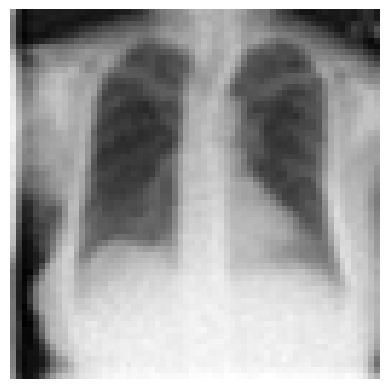

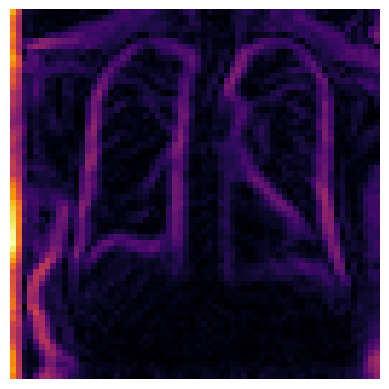

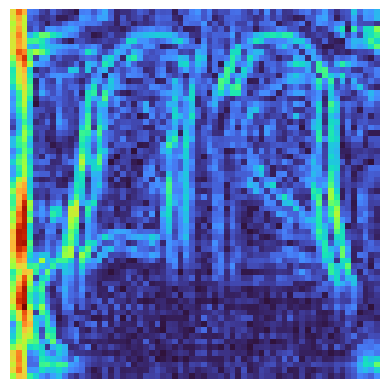

Method: chest_decor_0


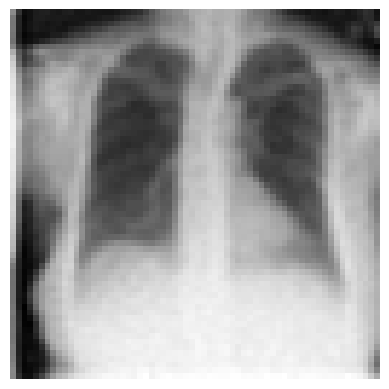

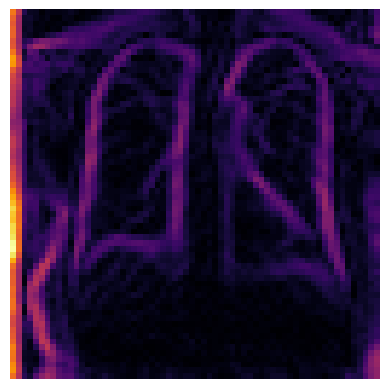

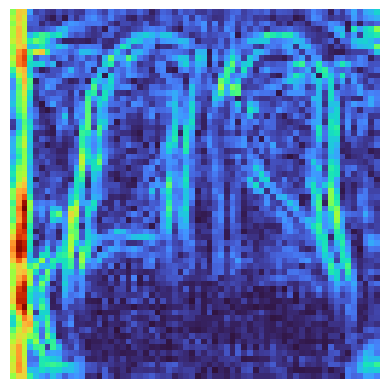

Method: chest_chebyshev_10


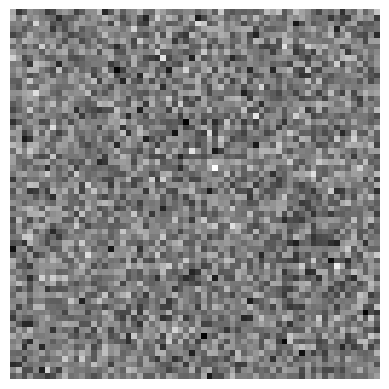

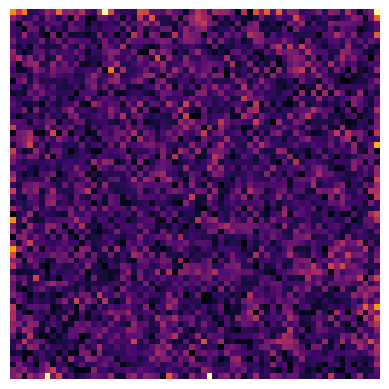

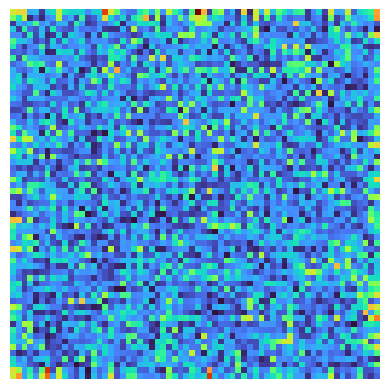

Method: chest_chebyshev_20


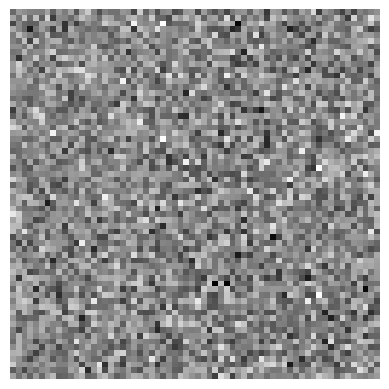

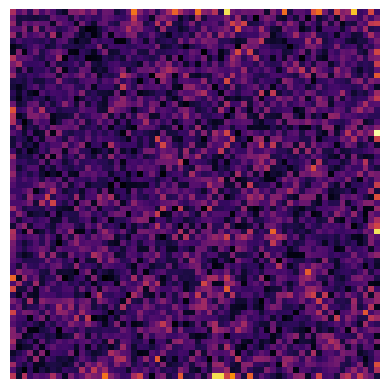

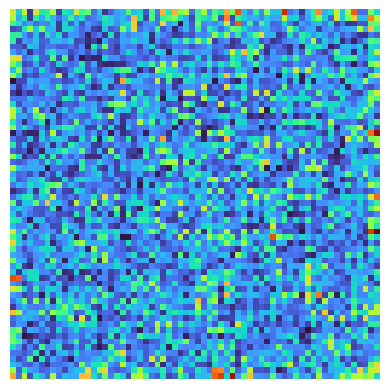

Method: oct_plain_0


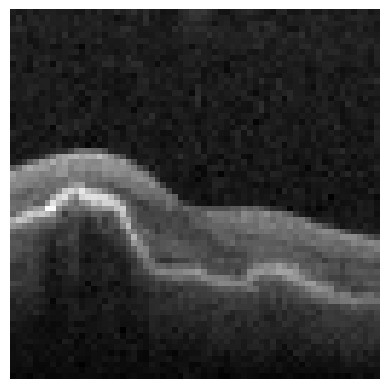

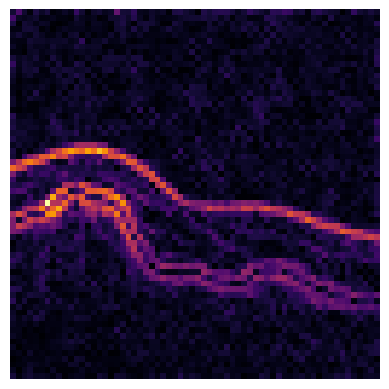

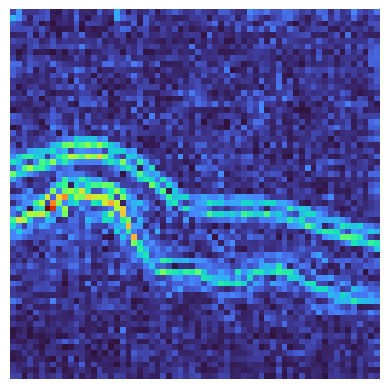

Method: oct_decor_0


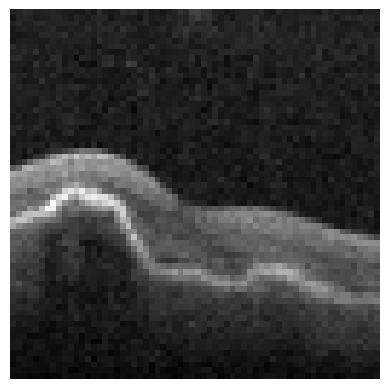

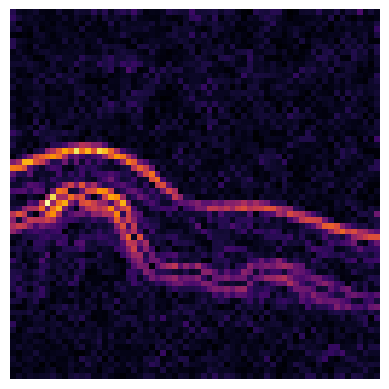

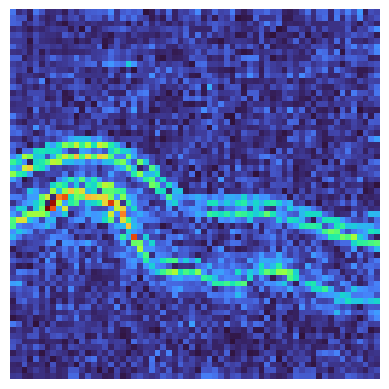

Method: oct_chebyshev_10


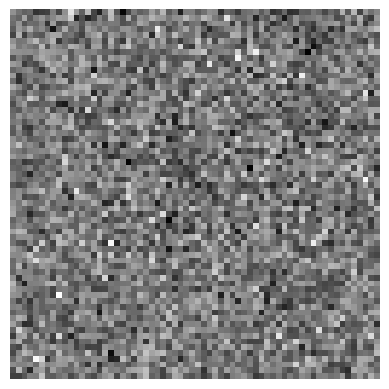

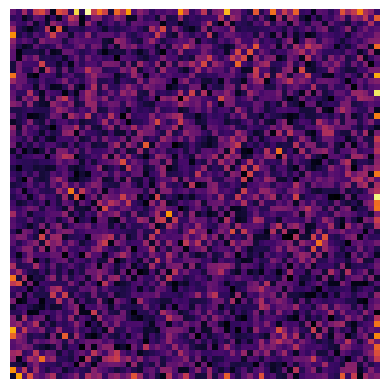

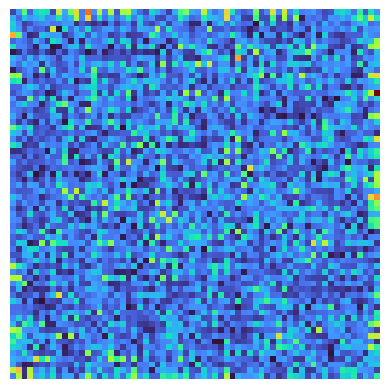

Method: oct_chebyshev_20


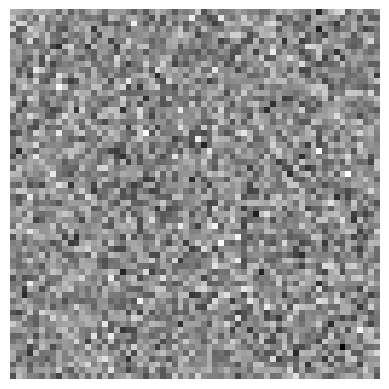

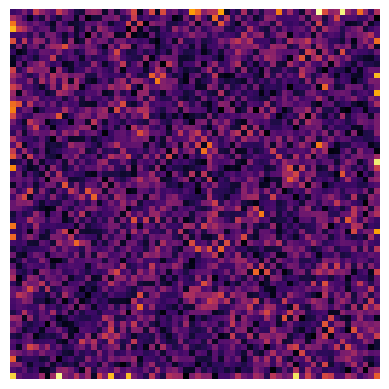

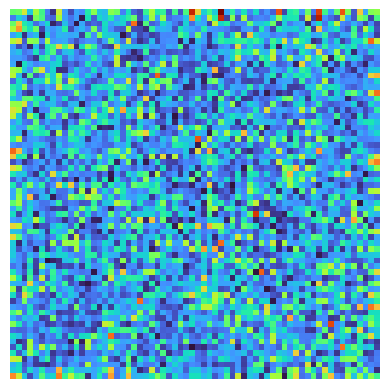

Method: organ_plain_0


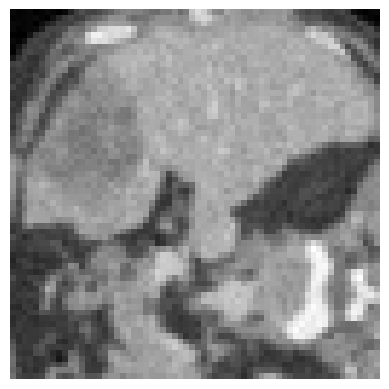

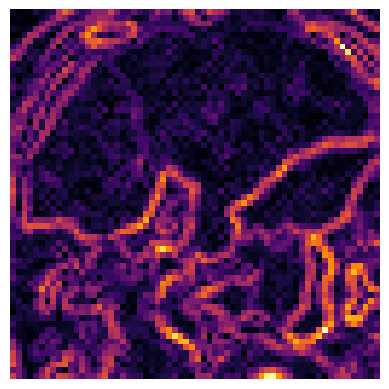

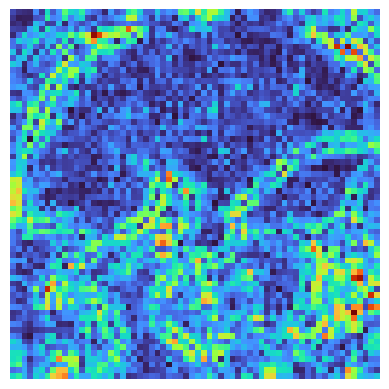

Method: organ_decor_0


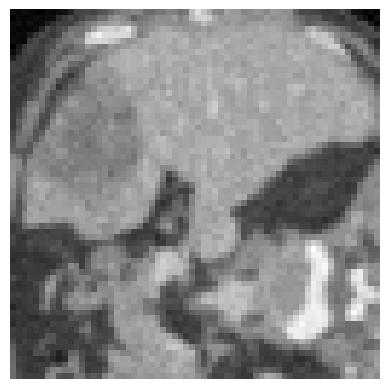

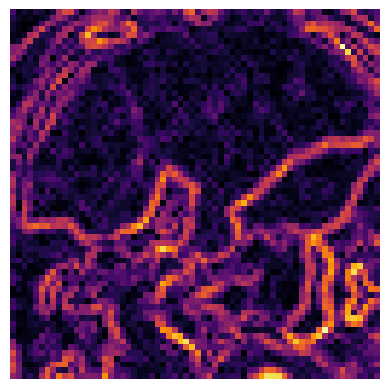

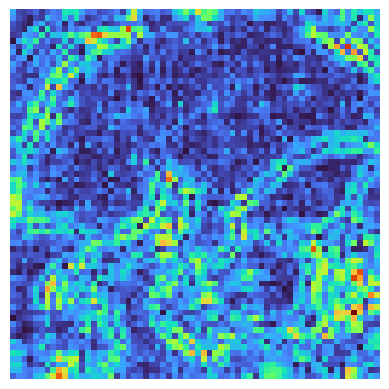

Method: organ_chebyshev_10


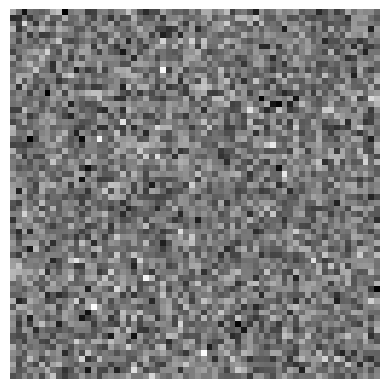

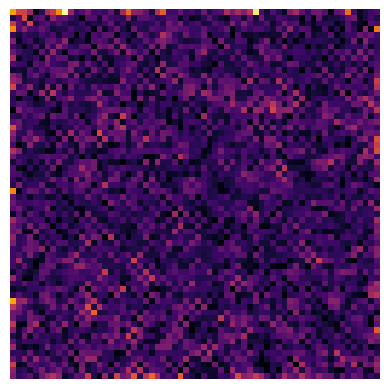

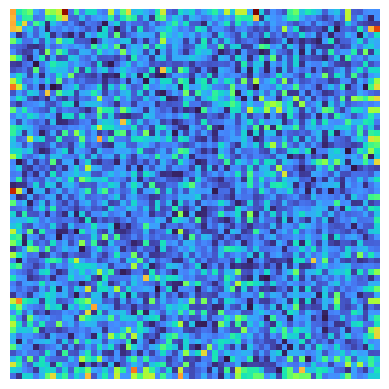

Method: organ_chebyshev_20


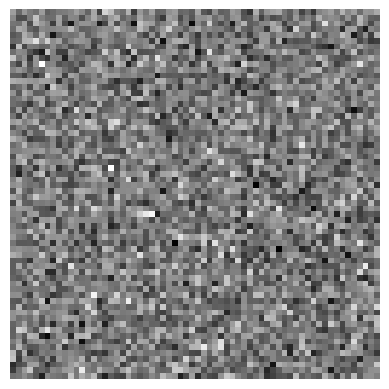

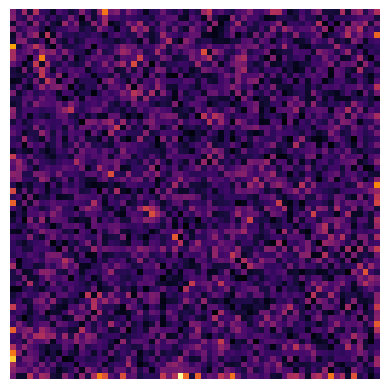

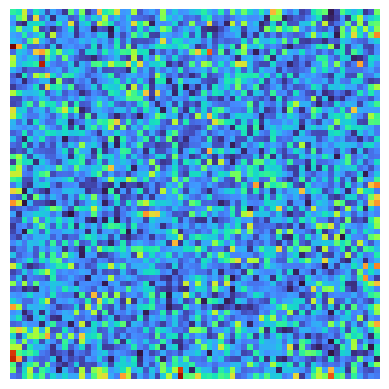

In [7]:
resolution = 64
approaches = [["chest_plain_0", "oct_plain_0", "organ_plain_0"],
              ["chest_decor_0", "oct_decor_0", "organ_decor_0"],
              ["chest_chebyshev_10", "oct_chebyshev_10", "organ_chebyshev_10"],
              ["chest_chebyshev_20", "oct_chebyshev_20", "organ_chebyshev_20"]]

# Transpose approaches so we iterate across modalities (chest/oct/organ) per method
approaches = [list(t) for t in zip(*approaches)]
approaches = [name for group in approaches for name in group]

for name in approaches:
    img = np.array(get_img_by_method(f"siren_{name}_img_64", siren_images_df))
    try:
        img = img.reshape(resolution, resolution)
    except:
        print(f"Could not reshape image for method {name}")
        continue
    
    # Compute the gradient of img
    gx, gy = np.gradient(img)
    grad_img = np.hypot(gx, gy)

    # Compute the divergence of the gradient
    gxx, _ = np.gradient(gx)
    _, gyy = np.gradient(gy)
    div_img = np.hypot(gxx, gyy)
    
    print(f"Method: {name}")    
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

    plt.imshow(grad_img, cmap='inferno')
    plt.axis('off')
    plt.show()

    plt.imshow(div_img, cmap='turbo')
    plt.axis('off')
    plt.show()

In [ ]:
def plot_scatter_baseline_refs(
        x, ys, labels=None, title="Scatter Plot",
        xlabel="X", ylabel="Y",
        plot_labels=False):
    """
    Plots a scatter plot with a baseline X and multiple reference Ys.

    Args:
        x (list or np.ndarray): Baseline X values.
        ys (list of lists or np.ndarrays): List of reference Y values.
        labels (list of str, optional): Labels for each Y reference.
        title (str, optional): Plot title.
        xlabel (str, optional): Label for X axis.
        ylabel (str, optional): Label for Y axis.
    """
    plt.figure(figsize=(8, 6))
    
    # draw identity (ground truth) diagonal and set equal aspect & limits
    arrs = [np.asarray(x)] + [np.asarray(y) for y in ys if y is not None]
    if len(arrs) > 0 and all(a.size > 0 for a in arrs):
        concat = np.concatenate([a.ravel() for a in arrs])
        mn, mx = float(concat.min()), float(concat.max())
        pad = (mx - mn) * 0.02 if mx > mn else 1.0
        line_x = np.linspace(mn - pad, mx + pad, 100)
        plt.plot(line_x, line_x, '--', color='tab:green', linewidth=0.77, label='Ground truth')
        plt.xlim(mn - pad, mx + pad)
        plt.ylim(mn - pad, mx + pad)
        plt.gca().set_aspect('equal', adjustable='box')
    
    for idx, y in enumerate(ys):
        label = labels[idx] if labels and idx < len(labels) else f"Ref {idx+1}"
        plt.scatter(x, y, label=label, s=10)

    if plot_labels:
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend()

    
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.tick_params(axis='both', which='minor', labelsize=19)
    plt.show()

In [5]:
def get_betas_by_method(method_name, df):
    row = df[df['Method'] == method_name]
    if not row.empty:
        return row.iloc[0]['Betas']
    return None

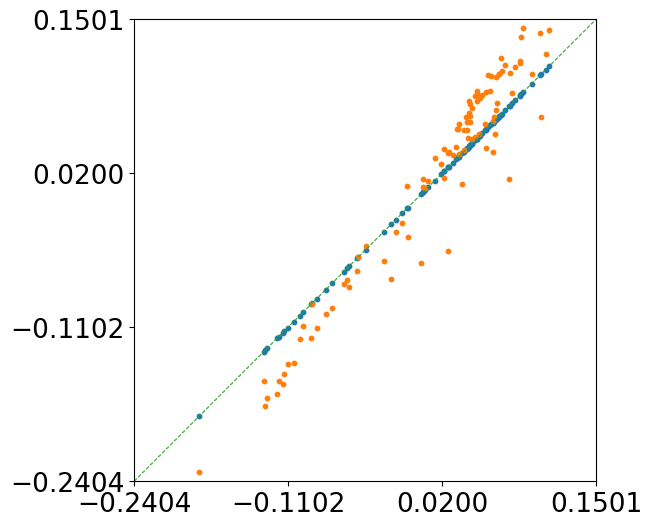

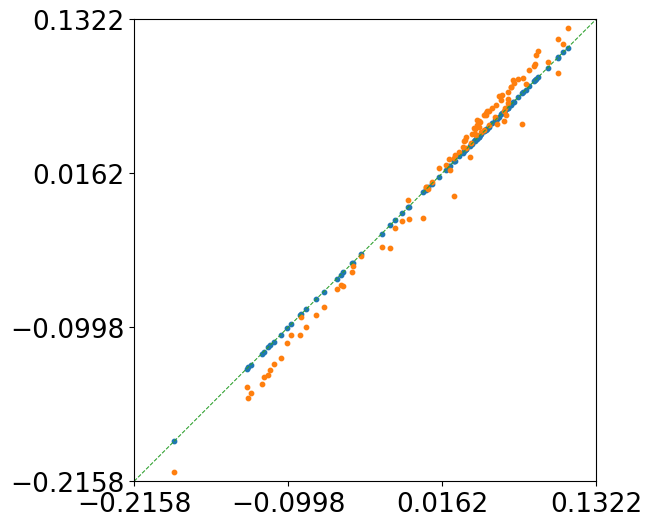

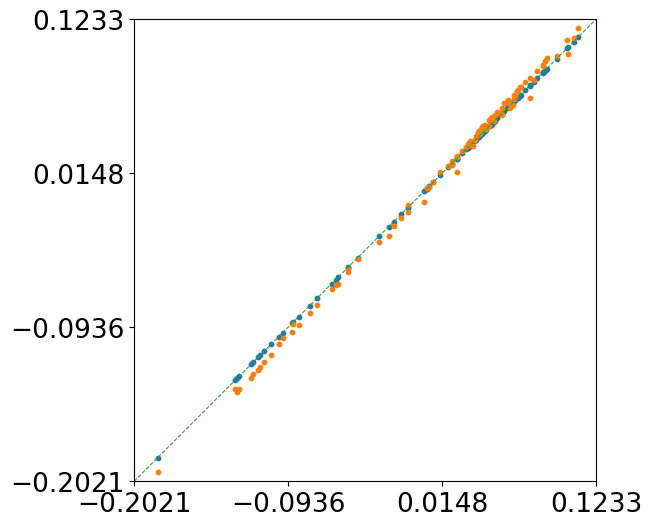

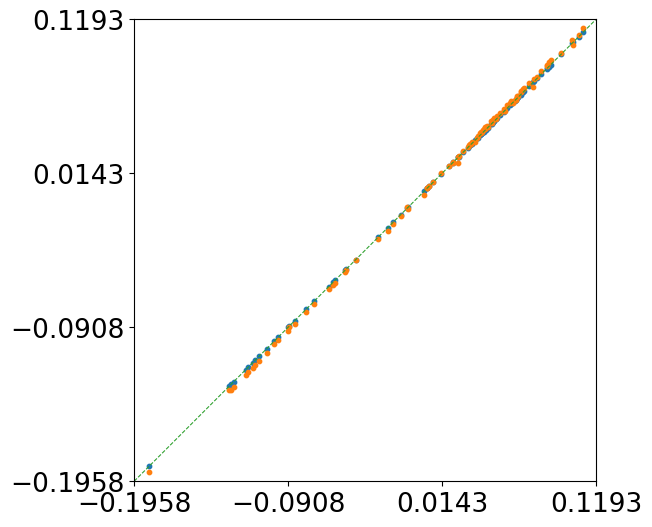

In [27]:
for degree in [20, 30, 40, 50]:
    plot_scatter_baseline_refs(
        x=get_betas_by_method(f"gwas_plaintext_betas_64", gwas_betas_df),
        ys=[
            get_betas_by_method(f"gwas_decor_betas_64", gwas_betas_df),
            get_betas_by_method(f"gwas_chebyshev_{degree}_betas_64", gwas_betas_df),
        ],
        labels=["Decor", "Chebyshev", "Fourier"],
        title=f"GWAS Betas Comparison {degree}",
        xlabel="Plaintext Betas",
        ylabel="Secure Betas")

In [ ]:
e2e_df[e2e_df['Method'].str.contains('siren')].sort_values(by='Accuracy', ascending=False)

In [ ]:
e2e_df[e2e_df['Method'].str.contains('gwas')].sort_values(by='Accuracy', ascending=False)